In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
from torch_geometric.utils import add_self_loops
from torch_geometric.nn import MessagePassing
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [53]:
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

In [54]:
data.train_mask.sum()

tensor(140)

In [55]:
data.x

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [56]:
num_nodes = data.num_nodes
indices = torch.randperm(num_nodes)  # random shuffle
train_size = int(0.7 * num_nodes)
val_size   = int(0.15 * num_nodes)
test_size  = num_nodes - train_size - val_size
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask   = torch.zeros(num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[indices[:train_size]] = True
val_mask[indices[train_size:train_size+val_size]] = True
test_mask[indices[train_size+val_size:]] = True
data.train_mask = train_mask
data.val_mask   = val_mask
data.test_mask  = test_mask

print("Train nodes:", train_mask.sum().item())
print("Validation nodes:", val_mask.sum().item())
print("Test nodes:", test_mask.sum().item())

Train nodes: 1895
Validation nodes: 406
Test nodes: 407


In [57]:
class NeutrosophicFuzzification(nn.Module):
    def __init__(self, alpha=0.5, beta=2.0, normalize=False):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.normalize = normalize

    def forward(self, x):
        # Compute feature-wise mean and std
        mean = x.mean(dim=0, keepdim=True)
        std = x.std(dim=0, keepdim=True) + 1e-6  # numerical stability

        # Truth membership
        T = torch.exp(-((x - mean) ** 2) / (2 * std ** 2))

        # Falsity membership
        F_ns = 1 - torch.exp(-((x - mean) ** 2) / (2 * (self.alpha * std) ** 2))

        # Indeterminacy membership
        I = 1 - torch.exp(-((x - mean) ** 2) / (2 * (self.beta * std) ** 2))

        # Optional normalization (recommended for stability)
        if self.normalize:
            denom = T + I + F_ns + 1e-6
            T = T / denom
            I = I / denom
            F_ns = F_ns / denom

        # Stack → (N, F, 3)
        combined = torch.stack([T, I, F_ns], dim=2)

        # 🔥 IMPORTANT: reshape for GNN → (N, F*3)
        combined = combined.view(x.size(0), -1)

        return combined


In [58]:

class NGNNLayer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')

        self.in_channels = in_channels
        self.out_channels = out_channels

        # Linear transformation: (F*3) → (F'*3)
        self.linear = nn.Linear(in_channels * 3, out_channels * 3)

    def forward(self, combined, edge_index):
        # combined: [N, F, 3]
        num_nodes = combined.size(0)

        # Add self-loops
        edge_index, _ = add_self_loops(edge_index, num_nodes=num_nodes)
        row, col = edge_index

        # --- Edge similarity using Truth channel ---
        T = combined[:, :, 0]  # [N, F]

        # Normalize before cosine similarity (IMPORTANT)
        T = F.normalize(T, p=2, dim=1)

        edge_sim = (T[row] * T[col]).sum(dim=1)  # safer than cosine_similarity

        # --- Edge fuzzification ---
        edge_T, edge_I, edge_F = self.fuzzify_edge(edge_sim)
        edge_weights = torch.stack([edge_T, edge_I, edge_F], dim=1)  # [E, 3]

        # --- Node transformation ---
        x_flat = combined.view(num_nodes, -1)  # [N, F*3]
        x_trans = self.linear(x_flat)          # [N, F'*3]

        # --- Propagation ---
        x_agg = self.propagate(edge_index, x=x_trans, edge_weights=edge_weights)

        # --- Residual connection ---
        x_out = x_trans + x_agg

        # --- Reshape back ---
        out = x_out.view(num_nodes, self.out_channels, 3)

        return out

    def message(self, x_j, edge_weights):
        # x_j: [E, F'*3]
        num_edges = x_j.size(0)

        # Reshape → [E, F', 3]
        x_j = x_j.view(num_edges, self.out_channels, 3)

        # Expand edge weights → [E, 1, 3]
        edge_weights = edge_weights.unsqueeze(1)

        # Channel-wise weighting
        out = x_j * edge_weights

        # Flatten → [E, F'*3]
        return out.view(num_edges, -1)

    def fuzzify_edge(self, edge_weight, beta=2.0):
        # Normalize similarity to [0,1]
        w = (edge_weight + 1) / 2

        # Clamp for numerical stability
        w = torch.clamp(w, 0.0, 1.0)

        # Neutrosophic edge components
        T_e = w
        I_e = torch.exp(-beta * (w - 0.5) ** 2)
        F_e = 1 - w

        return T_e, I_e, F_e

In [59]:
class NGNNLayer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')

        self.out_channels = out_channels
        self.linear = nn.Linear(in_channels * 3, out_channels * 3)

    def forward(self, combined, edge_index):
        num_nodes = combined.size(0)

        edge_index, _ = add_self_loops(edge_index, num_nodes=num_nodes)
        row, col = edge_index

        # 🔹 Step 1: flatten input
        x = combined.view(num_nodes, -1)  # [N, F*3]

        # 🔹 Step 2: edge similarity (use T)
        T = combined[:, :, 0]
        # edge_sim = F.cosine_similarity(T[row], T[col], dim=1)
        edge_sim = torch.cosine_similarity(T[row], T[col], dim=1)

        # 🔹 Step 3: fuzzify edges
        edge_T, edge_I, edge_F = self.fuzzify_edge(edge_sim)

        edge_combined = torch.stack([edge_T, edge_I, edge_F], dim=1)  # [E,3]

        # 🔹 Step 4: transform
        x_trans = self.linear(x)  # [N, out_channels*3]

        # 🔹 Step 5: propagate (flattened)
        out = self.propagate(edge_index, x=x_trans, edge_weight=edge_combined)

        # 🔹 Step 6: reshape AFTER propagation
        x_trans = x_trans.view(num_nodes, self.out_channels, 3)
        out = out.view(num_nodes, self.out_channels, 3)

        # 🔹 Step 7: residual
        out = x_trans + out

        return out

    def message(self, x_j, edge_weight):
        """
        x_j: [E, out_channels*3]
        edge_weight: [E, 3]
        """

        # reshape x_j → [E, out_channels, 3]
        x_j = x_j.view(-1, self.out_channels, 3)

        # apply weights
        edge_weight = edge_weight.unsqueeze(1)  # [E,1,3]
        out = x_j * edge_weight

        # flatten back
        return out.view(-1, self.out_channels * 3)

    def fuzzify_edge(self, edge_weight, beta=2.0):
        w = (edge_weight + 1) / 2

        T_e = w
        I_e = torch.exp(-beta * (w - 0.5)**2)
        F_e = 1 - w

        return T_e, I_e, F_e

In [60]:
class NGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()

        self.fuzz = NeutrosophicFuzzification()
        self.dropout = dropout
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels

        # ✅ Fixed layer definition
        self.layer1 = NGNNLayer(in_channels, hidden_channels)
        self.layer2 = NGNNLayer(hidden_channels, out_channels)

        # LayerNorm on flattened features
        self.norm1 = nn.LayerNorm(hidden_channels * 3)
        self.norm2 = nn.LayerNorm(out_channels * 3)

        # Learnable neutrosophic rule weights
        self.rule_weights = nn.Parameter(torch.tensor([1.0, 0.5, 0.5]))

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        num_nodes = x.size(0)

        # --- Step 1: Fuzzification ---
        # Output: [N, F, 3]
        combined = self.fuzz(x)

        # --- Step 2: Layer 1 ---
        combined = self.layer1(combined, edge_index)  # [N, hidden, 3]

        # Flatten → Norm → ReLU → Dropout
        combined = combined.view(num_nodes, -1)  # [N, hidden*3]
        combined = self.norm1(combined)
        combined = F.relu(combined)
        combined = F.dropout(combined, p=self.dropout, training=self.training)

        # Reshape back
        combined = combined.view(num_nodes, self.hidden_channels, 3)

        # --- Step 3: Layer 2 ---
        combined = self.layer2(combined, edge_index)  # [N, out, 3]

        # Flatten → Norm
        combined = combined.view(num_nodes, -1)  # [N, out*3]
        combined = self.norm2(combined)

        # Reshape back
        combined = combined.view(num_nodes, self.out_channels, 3)

        # --- Step 4: Defuzzification ---
        # Softmax ensures weights sum to 1
        weights = torch.softmax(self.rule_weights, dim=0)  # [3]

        # Weighted combination of (T, I, F)
        H = (combined * weights).sum(dim=2)  # [N, out_channels]

        # --- Step 5: Output ---
        return H, F.log_softmax(H, dim=1)

In [61]:
import torch

device = torch.device(
    'mps' if torch.backends.mps.is_available()
    else 'cuda' if torch.cuda.is_available()
    else 'cpu'
)

model = NGNN(
    in_channels=dataset.num_node_features,
    hidden_channels=128,
    out_channels=dataset.num_classes,
    dropout=0.3
).to(device)

data = data.to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=1e-4
)

AttributeError: partially initialized module 'torch_geometric' has no attribute 'typing' (most likely due to a circular import)

In [ ]:
T, I, F_val = model.fuzz(data.x)

print("Truth (T) for first 5 nodes:\n", T[:5])
print("\nIndeterminacy (I) for first 5 nodes:\n", I[:5])
print("\nFalsity (F) for first 5 nodes:\n", F_val[:5])

Truth (T) for first 5 nodes:
 tensor([[0.9970, 0.9939, 0.9868,  ..., 0.9989, 0.9878, 0.9978],
        [0.9970, 0.9939, 0.9868,  ..., 0.9989, 0.9878, 0.9978],
        [0.9970, 0.9939, 0.9868,  ..., 0.9989, 0.9878, 0.9978],
        [0.9970, 0.9939, 0.9868,  ..., 0.9989, 0.9878, 0.9978],
        [0.9970, 0.9939, 0.9868,  ..., 0.9989, 0.9878, 0.9978]])

Indeterminacy (I) for first 5 nodes:
 tensor([[0.0007, 0.0015, 0.0033,  ..., 0.0003, 0.0031, 0.0006],
        [0.0007, 0.0015, 0.0033,  ..., 0.0003, 0.0031, 0.0006],
        [0.0007, 0.0015, 0.0033,  ..., 0.0003, 0.0031, 0.0006],
        [0.0007, 0.0015, 0.0033,  ..., 0.0003, 0.0031, 0.0006],
        [0.0007, 0.0015, 0.0033,  ..., 0.0003, 0.0031, 0.0006]])

Falsity (F) for first 5 nodes:
 tensor([[0.0118, 0.0244, 0.0517,  ..., 0.0044, 0.0480, 0.0089],
        [0.0118, 0.0244, 0.0517,  ..., 0.0044, 0.0480, 0.0089],
        [0.0118, 0.0244, 0.0517,  ..., 0.0044, 0.0480, 0.0089],
        [0.0118, 0.0244, 0.0517,  ..., 0.0044, 0.0480, 0.0089],


In [ ]:
# def train():
#     model.train()
#     optimizer.zero_grad()
#     H,out = model(data)
#     loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
#     loss.backward()
#     optimizer.step()
#     return loss.item()

# def test():
#     model.eval()
#     with torch.no_grad():
#         H, out = model(data)   
        
#         pred = out.argmax(dim=1)

#         correct = pred[data.test_mask] == data.y[data.test_mask]
#         acc = int(correct.sum()) / int(data.test_mask.sum())

#     return acc

In [ ]:
best_val_acc = 0
best_model_state = None

for epoch in range(1, 501):
    model.train()
    optimizer.zero_grad()
    H, out = model(data)
    loss = torch.nn.functional.nll_loss(out[data.train_mask], data.y[data.train_mask].long())
    loss.backward()
    optimizer.step()
    
    model.eval()
    with torch.no_grad():
        H, out = model(data)
        pred = out.argmax(dim=1)
        
        val_correct = (pred[data.val_mask] == data.y[data.val_mask]).sum().item()
        val_acc = val_correct / data.val_mask.sum().item()
        
        test_correct = (pred[data.test_mask] == data.y[data.test_mask]).sum().item()
        test_acc = test_correct / data.test_mask.sum().item()
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

if best_model_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
    print(f"\nRestored best model with Val Acc: {best_val_acc:.4f}")

NameError: name 'model' is not defined

In [ ]:
for epoch in range(1, 501):
    loss = train()
    acc = test()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")

Epoch 10, Loss: 14.8613, Test Accuracy: 0.1941
Epoch 20, Loss: 1.8539, Test Accuracy: 0.2482
Epoch 30, Loss: 1.9094, Test Accuracy: 0.2482
Epoch 40, Loss: 1.8852, Test Accuracy: 0.2482
Epoch 50, Loss: 1.8759, Test Accuracy: 0.2482
Epoch 60, Loss: 1.8738, Test Accuracy: 0.2482
Epoch 70, Loss: 1.8735, Test Accuracy: 0.2482
Epoch 80, Loss: 1.8734, Test Accuracy: 0.2482
Epoch 90, Loss: 1.8731, Test Accuracy: 0.2482
Epoch 100, Loss: 1.8731, Test Accuracy: 0.2482
Epoch 110, Loss: 1.8728, Test Accuracy: 0.2482
Epoch 120, Loss: 1.8725, Test Accuracy: 0.2482
Epoch 130, Loss: 1.8723, Test Accuracy: 0.2482
Epoch 140, Loss: 1.8721, Test Accuracy: 0.2482
Epoch 150, Loss: 1.8718, Test Accuracy: 0.2482
Epoch 160, Loss: 1.8716, Test Accuracy: 0.2482
Epoch 170, Loss: 1.8714, Test Accuracy: 0.2482
Epoch 180, Loss: 1.8711, Test Accuracy: 0.2482
Epoch 190, Loss: 1.8716, Test Accuracy: 0.2482
Epoch 200, Loss: 1.8743, Test Accuracy: 0.2482
Epoch 210, Loss: 1.8733, Test Accuracy: 0.2482
Epoch 220, Loss: 1.87

In [ ]:
def get_embeddings():
    model.eval()
    with torch.no_grad():
        H, out = model(data)
    return H

In [ ]:
H = get_embeddings()

print("Shape of X_new:", H.shape)
print("\nFirst 5 nodes (X_new):\n", H[:5])

Shape of X_new: torch.Size([2708, 7])

First 5 nodes (X_new):
 tensor([[-7.4930e-02, -4.0123e-01, -6.2937e-03,  3.5270e-01, -2.2604e-02,
         -2.2625e-01, -7.1470e-01],
        [-7.4930e-02, -4.0123e-01, -6.2937e-03,  3.5270e-01, -2.2604e-02,
         -2.2625e-01, -7.1470e-01],
        [-8.4872e-02, -5.4215e-01, -1.1648e-02,  4.7056e-01, -9.7498e-03,
         -3.1279e-01, -9.6427e-01],
        [-6.4989e-02, -2.6032e-01, -9.3937e-04,  2.3483e-01, -3.5459e-02,
         -1.3971e-01, -4.6514e-01],
        [-8.4872e-02, -5.4215e-01, -1.1648e-02,  4.7056e-01, -9.7498e-03,
         -3.1279e-01, -9.6427e-01]])


In [ ]:
def get_predictions():
    model.eval()
    with torch.no_grad():
        H, out = model(data)
        pred = out.argmax(dim=1)
    return pred

In [ ]:
pred = get_predictions()

print("First 20 nodes classification:\n")
for i in range(50):
    print(f"Node {i}: Predicted = {pred[i].item()}, Actual = {data.y[i].item()}")

First 20 nodes classification:

Node 0: Predicted = 3, Actual = 3
Node 1: Predicted = 3, Actual = 4
Node 2: Predicted = 3, Actual = 4
Node 3: Predicted = 3, Actual = 0
Node 4: Predicted = 3, Actual = 3
Node 5: Predicted = 3, Actual = 2
Node 6: Predicted = 3, Actual = 0
Node 7: Predicted = 3, Actual = 3
Node 8: Predicted = 3, Actual = 3
Node 9: Predicted = 3, Actual = 2
Node 10: Predicted = 3, Actual = 0
Node 11: Predicted = 3, Actual = 0
Node 12: Predicted = 3, Actual = 4
Node 13: Predicted = 3, Actual = 3
Node 14: Predicted = 3, Actual = 3
Node 15: Predicted = 3, Actual = 3
Node 16: Predicted = 3, Actual = 2
Node 17: Predicted = 3, Actual = 3
Node 18: Predicted = 3, Actual = 1
Node 19: Predicted = 3, Actual = 3
Node 20: Predicted = 3, Actual = 5
Node 21: Predicted = 3, Actual = 3
Node 22: Predicted = 3, Actual = 4
Node 23: Predicted = 3, Actual = 6
Node 24: Predicted = 3, Actual = 3
Node 25: Predicted = 3, Actual = 3
Node 26: Predicted = 3, Actual = 6
Node 27: Predicted = 3, Actual = 

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

def evaluate_metrics():
    model.eval()
    with torch.no_grad():
        H, out = model(data)
        pred = out.argmax(dim=1).cpu()
        true = data.y.cpu()

        # Only consider test nodes
        test_idx = data.test_mask.cpu()
        y_true = true[test_idx]
        y_pred = pred[test_idx]

        # Compute metrics
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')  # macro = average over classes
        precision = precision_score(y_true, y_pred, average='macro')
        recall = recall_score(y_true, y_pred, average='macro')
        cm = confusion_matrix(y_true, y_pred)

    return acc, precision, recall, f1, cm

In [ ]:
# After training is done
acc, precision, recall, f1, cm = evaluate_metrics()

print(f"Test Accuracy  : {acc:.4f}")
print(f"Test Precision : {precision:.4f}")
print(f"Test Recall    : {recall:.4f}")
print(f"Test F1 Score  : {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

Test Accuracy  : 0.2924
Test Precision : 0.0418
Test Recall    : 0.1429
Test F1 Score  : 0.0646

Confusion Matrix:
[[  0   0   0  52   0   0   0]
 [  0   0   0  34   0   0   0]
 [  0   0   0  60   0   0   0]
 [  0   0   0 119   0   0   0]
 [  0   0   0  62   0   0   0]
 [  0   0   0  45   0   0   0]
 [  0   0   0  35   0   0   0]]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
data.y[20].item()

5

In [ ]:
# Make predictions
model.eval()
with torch.no_grad():
    H, out = model(data)
    pred = out.argmax(dim=1)

# Only consider test nodes
test_idx = data.test_mask.nonzero(as_tuple=True)[0]
y_true = data.y[test_idx]
y_pred = pred[test_idx]

# Find misclassified nodes
wrong_idx = test_idx[y_true != y_pred]

print(f"Total wrong predictions in test set: {len(wrong_idx)}\n")
print("List of misclassified nodes (Node ID : Predicted -> Actual):")
for node in wrong_idx:
    print(f"Node {node.item()}: Pred = {y_pred[node == test_idx].item()}, Actual = {y_true[node == test_idx].item()}")

Total wrong predictions in test set: 288

List of misclassified nodes (Node ID : Predicted -> Actual):
Node 1: Pred = 3, Actual = 4
Node 3: Pred = 3, Actual = 0
Node 6: Pred = 3, Actual = 0
Node 12: Pred = 3, Actual = 4
Node 28: Pred = 3, Actual = 2
Node 38: Pred = 3, Actual = 4
Node 43: Pred = 3, Actual = 4
Node 54: Pred = 3, Actual = 1
Node 60: Pred = 3, Actual = 0
Node 65: Pred = 3, Actual = 0
Node 75: Pred = 3, Actual = 4
Node 77: Pred = 3, Actual = 6
Node 87: Pred = 3, Actual = 6
Node 88: Pred = 3, Actual = 0
Node 89: Pred = 3, Actual = 4
Node 99: Pred = 3, Actual = 6
Node 104: Pred = 3, Actual = 1
Node 118: Pred = 3, Actual = 6
Node 119: Pred = 3, Actual = 5
Node 134: Pred = 3, Actual = 1
Node 156: Pred = 3, Actual = 2
Node 163: Pred = 3, Actual = 5
Node 193: Pred = 3, Actual = 5
Node 195: Pred = 3, Actual = 0
Node 202: Pred = 3, Actual = 2
Node 206: Pred = 3, Actual = 2
Node 245: Pred = 3, Actual = 4
Node 276: Pred = 3, Actual = 0
Node 282: Pred = 3, Actual = 5
Node 284: Pred = 

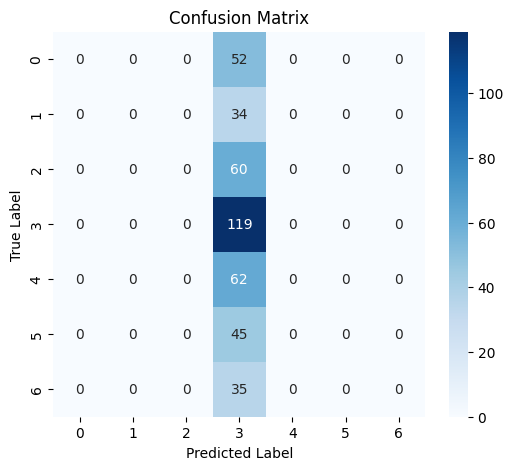

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

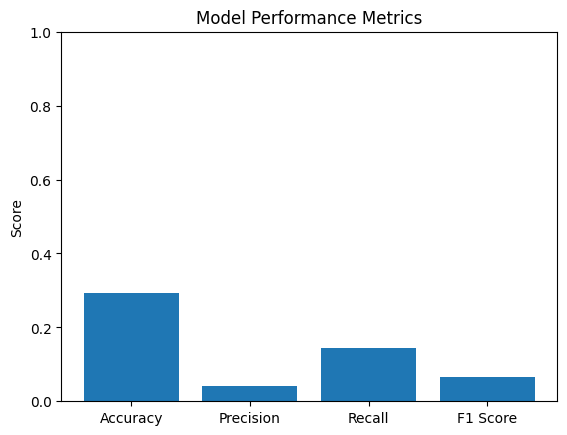

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [acc, precision, recall, f1]

plt.figure()
plt.bar(metrics, values)

plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.show()

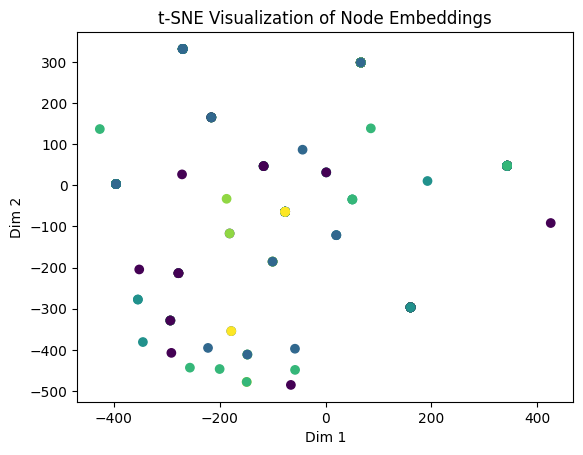

In [ ]:
from sklearn.manifold import TSNE

model.eval()
with torch.no_grad():
    H, out = model(data)   # H = embeddings

# Take only test nodes
test_idx = data.test_mask.cpu()
H_test = H[test_idx].cpu().numpy()
y_test = data.y[test_idx].cpu().numpy()

# Reduce to 2D
tsne = TSNE(n_components=2, random_state=42)
H_2d = tsne.fit_transform(H_test)

# Plot
plt.figure()
plt.scatter(H_2d[:,0], H_2d[:,1], c=y_test)

plt.title("t-SNE Visualization of Node Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.show()

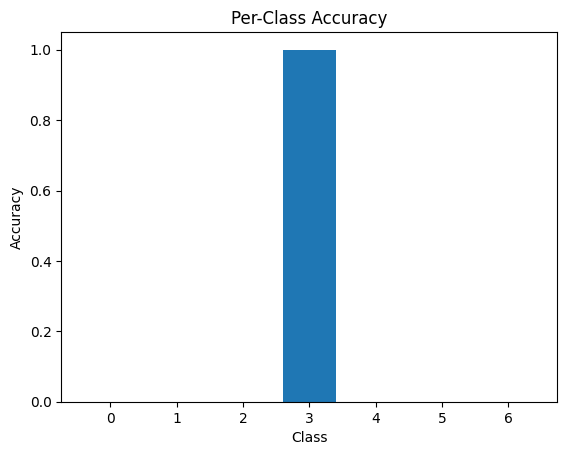

In [ ]:
import numpy as np

num_classes = cm.shape[0]
class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure()
plt.bar(range(num_classes), class_acc)

plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")

plt.show()